<a href="https://colab.research.google.com/github/abhinavmishragsv-analytics/Future-Customer-Booking-Prediction/blob/main/BritishAirways.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Our aim is to find if a customer would love to book with British Airways for their holidays.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 14 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   num_passengers         50000 non-null  int64  
 1   sales_channel          50000 non-null  object 
 2   trip_type              50000 non-null  object 
 3   purchase_lead          50000 non-null  int64  
 4   length_of_stay         50000 non-null  int64  
 5   flight_hour            50000 non-null  int64  
 6   flight_day             50000 non-null  object 
 7   route                  50000 non-null  object 
 8   booking_origin         50000 non-null  object 
 9   wants_extra_baggage    50000 non-null  int64  
 10  wants_preferred_seat   50000 non-null  int64  
 11  wants_in_flight_meals  50000 non-null  int64  
 12  flight_duration        50000 non-null  float64
 13  booking_complete       50000 non-null  int64  
dtypes: float64(1), int64(8), object(5)
memory usage: 5.3+ 

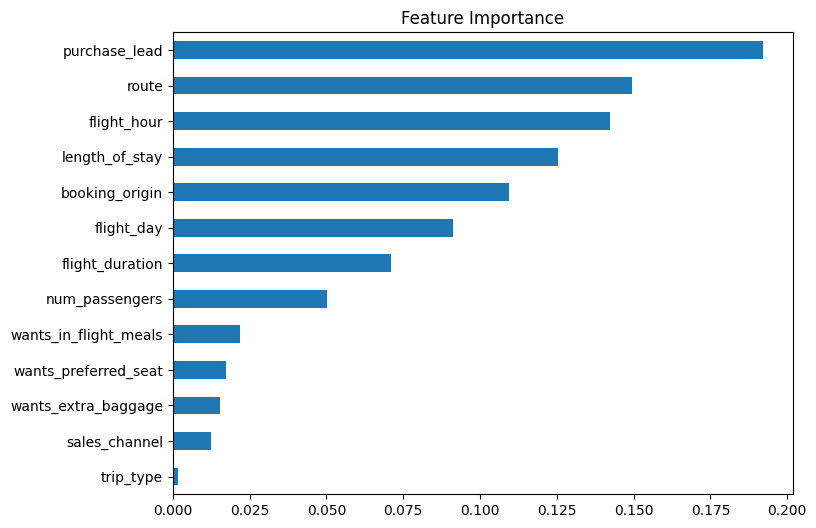

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,classification_report,roc_auc_score


df=pd.read_csv("customer_booking.csv",encoding="latin1")
df.head()
df.info()
categorical_cols=['sales_channel','trip_type','flight_day','route','booking_origin']
le=LabelEncoder()
for col in categorical_cols:
    df[col]=le.fit_transform(df[col])
x=df.drop("booking_complete",axis=1)
y=df["booking_complete"]
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)  ## 80% training,20% testing
rf=RandomForestClassifier(n_estimators=100,random_state=42)
rf.fit(x_train,y_train)
y_pred=rf.predict(x_test)
accuracy=accuracy_score(y_test,y_pred)
print("Accuracy",accuracy)
print(classification_report(y_test,y_pred))
print("AUC Score",roc_auc_score(y_test,y_pred))
customer = x_test.iloc[0:1]
prob = rf.predict_proba(customer)
print("Probability of booking:", prob[0][1])
importance = pd.Series(rf.feature_importances_, index=x.columns)
print(importance.sort_values(ascending=False))
importance.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance")
plt.show()